<a href="https://colab.research.google.com/github/mitch222/Trends_Campaings/blob/main/Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytrends
!pip install plotly

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from pytrends.request import TrendReq
from datetime import datetime

# Configuración visual
plt.style.use("ggplot")

In [ ]:
pytrends = TrendReq(
    hl='es-CO',
    tz=360
)

In [ ]:
brands = [
    "Nu",
    "Nequi",
    "Daviplata",
    "Lulo Bank",
    "Dolar App",
]

In [ ]:
pytrends.build_payload(
    kw_list=brands,
    timeframe='today 12-m',
    geo='CO'
)

trends_df = pytrends.interest_over_time()

# Eliminar columna isPartial si existe
if 'isPartial' in trends_df.columns:
    trends_df = trends_df.drop(columns=['isPartial'])

# Mostrar primeras filas
print("=== DATOS HISTÓRICOS ===")
display(trends_df.head())

=== DATOS HISTÓRICOS ===


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Nu,Nequi,Daviplata,Lulo Bank,Dolar App
date,,,,,
2025-05-18,9,53,6,1,0
2025-05-25,10,55,6,1,0
2025-06-01,10,53,6,1,0
2025-06-08,9,48,6,1,0
2025-06-15,9,52,7,1,0


In [ ]:
trends_df.to_csv(
    "google_trends_raw.csv",
    index=True
)

print("Archivo guardado: google_trends_raw.csv")

Archivo guardado: google_trends_raw.csv


In [ ]:
# Convertir índice a columna fecha
trends_clean = trends_df.reset_index()

# Renombrar columnas
trends_clean.rename(columns={
    'date': 'Fecha'
}, inplace=True)

# Convertir a formato largo
trends_long = trends_clean.melt(
    id_vars='Fecha',
    var_name='Marca',
    value_name='Interes'
)

print("=== DATOS LIMPIOS ===")
display(trends_long.head())


=== DATOS LIMPIOS ===


,Fecha,Marca,Interes
0,2025-05-18,Nu,9
1,2025-05-25,Nu,10
2,2025-06-01,Nu,10
3,2025-06-08,Nu,9
4,2025-06-15,Nu,9


In [ ]:
avg_interest = (
    trends_long
    .groupby("Marca")["Interes"]
    .mean()
    .sort_values(ascending=False)
)

print("\n=== PROMEDIO DE INTERÉS ===")
print(avg_interest)



=== PROMEDIO DE INTERÉS ===
Marca
Nequi        55.264151
Nu           10.358491
Daviplata     6.924528
Lulo Bank     1.018868
Dolar App     0.169811
Name: Interes, dtype: float64


In [ ]:
growth_data = []

for brand in brands:

    initial_value = trends_df[brand].iloc[0]
    final_value = trends_df[brand].iloc[-1]

    if initial_value == 0:
        growth = np.nan
    else:
        growth = ((final_value - initial_value) / initial_value) * 100

    growth_data.append({
        "Marca": brand,
        "Crecimiento (%)": round(growth, 2)
    })

growth_df = pd.DataFrame(growth_data)

print("\n=== CRECIMIENTO ===")
display(growth_df)


=== CRECIMIENTO ===


,Marca,Crecimiento (%)
0,Nu,33.33
1,Nequi,-18.87
2,Daviplata,0.00
3,Lulo Bank,0.00
4,Dolar App,NaN


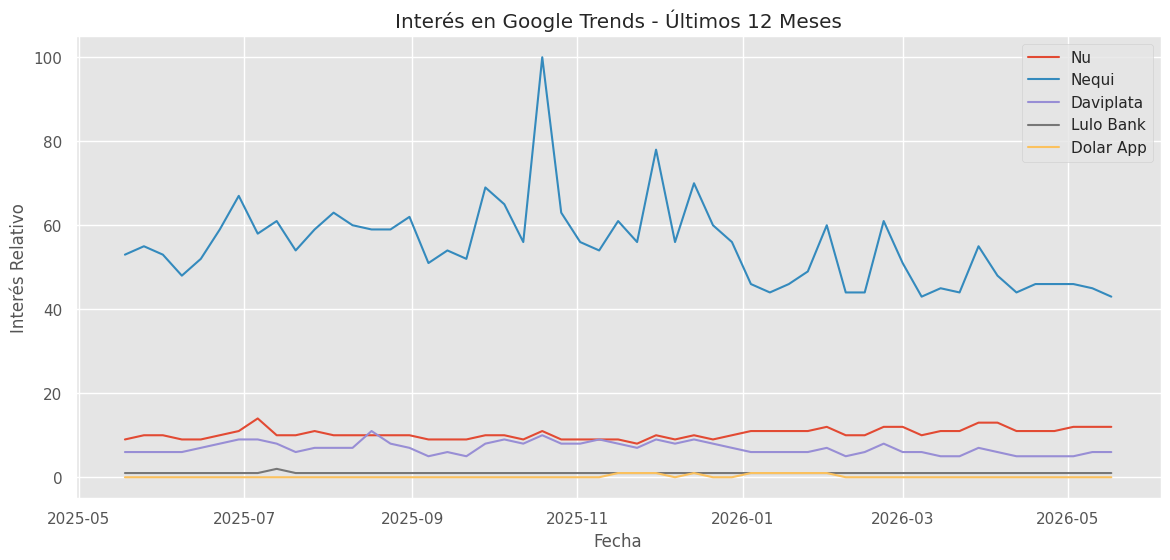

In [ ]:
plt.figure(figsize=(14,6))

for brand in brands:
    plt.plot(
        trends_df.index,
        trends_df[brand],
        label=brand
    )

plt.title("Interés en Google Trends - Últimos 12 Meses")
plt.xlabel("Fecha")
plt.ylabel("Interés Relativo")
plt.legend()
plt.show()

In [ ]:
fig = px.line(
    trends_long,
    x="Fecha",
    y="Interes",
    color="Marca",
    title="Tendencias Digitales Fintech en Colombia"
)

fig.show()


In [ ]:
region_frames = []

for brand in brands:

    pytrends.build_payload(
        kw_list=[brand],
        timeframe='today 12-m',
        geo='CO'
    )

    region_df = pytrends.interest_by_region()

    region_df = region_df.reset_index()

    region_df["Marca"] = brand

    region_frames.append(region_df)

regions_final = pd.concat(region_frames)

print("\n=== INTERÉS POR REGIÓN ===")
display(regions_final.head())

# Guardar regiones
regions_final.to_csv(
    "google_trends_regions.csv",
    index=False
)



=== INTERÉS POR REGIÓN ===


,geoName,Nu,Marca,Nequi,Daviplata,Lulo Bank
0,Amazonas,60.0,Nu,NaN,NaN,NaN
1,Antioquia,89.0,Nu,NaN,NaN,NaN
2,Arauca,49.0,Nu,NaN,NaN,NaN
3,Atlántico,71.0,Nu,NaN,NaN,NaN
4,Bogotá,100.0,Nu,NaN,NaN,NaN


In [ ]:
peak_data = []

for brand in brands:

    max_value = trends_df[brand].max()
    max_date = trends_df[brand].idxmax()

    peak_data.append({
        "Marca": brand,
        "Pico Máximo": max_value,
        "Fecha Pico": max_date
    })

peaks_df = pd.DataFrame(peak_data)

print("\n=== PICOS DE INTERÉS ===")
display(peaks_df)


=== PICOS DE INTERÉS ===


,Marca,Pico Máximo,Fecha Pico
0,Nu,14,2025-07-06
1,Nequi,100,2025-10-19
2,Daviplata,11,2025-08-17
3,Lulo Bank,2,2025-07-13


In [ ]:
top_brand = avg_interest.idxmax()

print("\n================ INSIGHTS =================")
print(f"La marca con mayor interés promedio es: {top_brand}")

fastest_growth = growth_df.sort_values(
    "Crecimiento (%)",
    ascending=False
).iloc[0]["Marca"]

print(f"La marca con mayor crecimiento es: {fastest_growth}")

print("Se recomienda revisar campañas y eventos")
print("relacionados con los picos detectados.")


================ INSIGHTS =================
La marca con mayor interés promedio es: Nequi
La marca con mayor crecimiento es: Nu
Se recomienda revisar campañas y eventos
relacionados con los picos detectados.


In [ ]:
trends_long.to_csv(
    "trends_long.csv",
    index=False
)

growth_df.to_csv(
    "growth_metrics.csv",
    index=False
)

peaks_df.to_csv(
    "peak_metrics.csv",
    index=False
)

print("\nArchivos exportados correctamente.")



Archivos exportados correctamente.


In [ ]:
# Simulación de métricas
np.random.seed(42)

marketing_df = pd.DataFrame({
    "Marca": brands,
    "Clicks": np.random.randint(1000, 10000, size=4),
    "Impressions": np.random.randint(20000, 100000, size=4),
    "Spend": np.random.randint(500, 5000, size=4),
    "Conversions": np.random.randint(100, 1500, size=4),
    "Revenue": np.random.randint(5000, 50000, size=4)
})

# KPIs
marketing_df["CTR"] = (
    marketing_df["Clicks"] /
    marketing_df["Impressions"]
) * 100

marketing_df["CPC"] = (
    marketing_df["Spend"] /
    marketing_df["Clicks"]
)

marketing_df["Conversion Rate"] = (
    marketing_df["Conversions"] /
    marketing_df["Clicks"]
) * 100

marketing_df["ROI"] = (
    (
        marketing_df["Revenue"] -
        marketing_df["Spend"]
    ) /
    marketing_df["Spend"]
) * 100

print("\n=== KPIs DE MARKETING ===")
display(marketing_df)

# Exportar KPIs
marketing_df.to_csv(
    "marketing_kpis.csv",
    index=False
)


=== KPIs DE MARKETING ===


,Marca,Clicks,Impressions,Spend,Conversions,Revenue,CTR,CPC,Conversion Rate,ROI
0,Nu,8270,96820,3944,1432,7433,8.541624,0.476904,17.315599,88.463489
1,Nequi,1860,74886,3671,869,10311,2.483775,1.973656,46.720430,180.877145
2,Daviplata,6390,26265,3419,443,42819,24.328955,0.535055,6.932707,1152.383738
3,Lulo Bank,6191,57194,630,905,44188,10.824562,0.101761,14.617994,6913.968254
